In [51]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tslearn.datasets import UCR_UEA_datasets

from uni2ts.model.moirai import MoiraiModule
from uni2ts.common.torch_util import packed_attention_mask
from encoder import MoiraiEncoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SIZE = "small"
NUM_VARS = 6
BATCH_SIZE = 256

In [60]:
from tqdm.auto import tqdm

def train_and_evaluate(
    model, 
    train_loader, 
    test_loader, 
    epochs=100, 
    lr=1e-3, 
    weight_decay=0.01,
    optimizer_name="AdamW",
    scheduler_patience=10,
    early_stopping_patience=20,
    clip_grad_norm=1.0,
    device=DEVICE,
    verbose=True
):
    """
    Boucle d'entraînement avancée pour la recherche.
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # 1. Sélection de l'optimiseur
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if optimizer_name.lower() == "adamw":
        optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        optimizer = optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(trainable_params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    else:
        raise ValueError(f"Optimizer {optimizer_name} non supporté.")
        
    # 2. Scheduler : Réduit le LR par 2 si la Test Acc ne s'améliore pas après X époques
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=scheduler_patience)
    
    # 3. Suivi et Checkpointing
    history = {'train_loss': [], 'test_loss': [], 'test_acc': [], 'lr': []}
    best_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        
        # --- ENTRAÎNEMENT ---
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{epochs} [Train]", leave=False, disable=not verbose)
        for batch in train_bar:
            x_target, x_obs, x_pad, y = [b.to(device) for b in batch]
            
            optimizer.zero_grad()
            logits = model(x_target, x_obs, x_pad)
            loss = criterion(logits, y)
            loss.backward()
            
            # Gradient clipping pour stabiliser le Transformer
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
                
            optimizer.step()
            total_train_loss += loss.item() * y.size(0)
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        
        # --- ÉVALUATION ---
        model.eval()
        total_test_loss = 0.0
        correct, total = 0, 0
        
        test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1:03d}/{epochs} [Test]", leave=False, disable=not verbose)
        with torch.no_grad():
            for batch in test_bar:
                x_target, x_obs, x_pad, y = [b.to(device) for b in batch]
                
                logits = model(x_target, x_obs, x_pad)
                loss = criterion(logits, y)
                total_test_loss += loss.item() * y.size(0)
                
                predictions = torch.argmax(logits, dim=-1)
                correct += (predictions == y).sum().item()
                total += y.size(0)
                
        avg_test_loss = total_test_loss / total
        test_acc = correct / total
        
        # Mise à jour du Scheduler
        scheduler.step(test_acc)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Sauvegarde de l'historique
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_acc)
        history['lr'].append(current_lr)
        
        if verbose:
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Test Loss: {avg_test_loss:.4f} | "
                  f"Test Acc: {test_acc:.4f} | "
                  f"LR: {current_lr:.2e}")
            
        # --- EARLY STOPPING & CHECKPOINTING ---
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= early_stopping_patience:
            if verbose:
                print(f"\n[!] Early stopping déclenché après {epoch+1} époques.")
            break
            
    # Chargement des poids du MEILLEUR modèle avant de le retourner
    model.load_state_dict(best_model_weights)
    if verbose:
        print(f"--- Entraînement Terminé. Meilleure Test Acc: {best_acc:.4f} ---")
        
    return history

In [61]:
def preprocess_data(
    data: np.ndarray,
    *,
    device: str | torch.device = "cpu",
    dtype: torch.dtype = torch.float32,
):
    """
    data: np.ndarray of shape (N, T, V) = (n_individual, time, variate)
    Assumes NO missing values and NO padding in the raw data.
    """

    if not isinstance(data, np.ndarray):
        raise TypeError("data must be a numpy.ndarray")
    if data.ndim != 3:
        raise ValueError(f"Expected shape (N,T,V), got {data.shape}")

    N, T, V = data.shape

    # (N,T,V)
    past_target = torch.as_tensor(data, dtype=dtype, device=device)

    # observed mask: (N,T,V) all True no missing values
    past_observed_target = torch.ones((N, T, V), dtype=torch.bool, device=device)

    # padding mask: (N,T) all if no padding
    past_is_pad = torch.zeros((N, T), dtype=torch.bool, device=device)

    return past_target, past_observed_target, past_is_pad

In [62]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

n_classes = len(set(y_train))
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train_tensor = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

NUM_CLASSES = len(torch.unique(y_train_tensor))

In [63]:
X_train_target_tensor, X_train_is_target_observed, X_train_is_target_padded = (
    preprocess_data(X_train, device=DEVICE)
)

X_test_target_tensor, X_test_is_target_observed, X_test_is_target_padded = (
    preprocess_data(X_test, device=DEVICE)
)
y_train_tensor = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

num_classes = len(torch.unique(y_train_tensor))
NUM_VARS = 6

print(X_train_target_tensor.shape)
print(X_train_is_target_observed.shape)
print(X_train_is_target_padded.shape)

torch.Size([2459, 36, 6])
torch.Size([2459, 36, 6])
torch.Size([2459, 36])


In [64]:
BATCH_SIZE = 64*2**2

# Création des Datasets
train_dataset = TensorDataset(
    X_train_target_tensor, 
    X_train_is_target_observed, 
    X_train_is_target_padded, 
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_target_tensor, 
    X_test_is_target_observed, 
    X_test_is_target_padded, 
    y_test_tensor
)

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class MoiraiForClassification(nn.Module):
    def __init__(self, moirai_encoder, num_classes, num_vars, d_model=384, dropout = 0.3):
        super().__init__()
        self.moirai = moirai_encoder
        self.num_vars = num_vars
        
        head_input_dim = num_vars * d_model
        
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(head_input_dim, num_classes)

    def forward(self, past_target, past_observed_target, past_is_pad):
        reprs = self.moirai(
            past_target=past_target,
            past_observed_target=past_observed_target,
            past_is_pad=past_is_pad
        )
        
        N, S, F = reprs.shape
        P = S // self.num_vars
        
        reprs_reshaped = reprs.view(N, self.num_vars, P, F)
        mask_reprs = reprs_reshaped[:, :, -1, :]
        
        pooled = mask_reprs.reshape(N, -1)
        pooled = self.dropout(pooled)
        logits = self.head(pooled)
        return logits

    def set_tuning_mode(self, tune_mask=True):
        for param in self.moirai.parameters():
            param.requires_grad = False
            
        if tune_mask:
            self.moirai.module.mask_encoding.weight.requires_grad = True
            
        for param in self.head.parameters():
            param.requires_grad = True
            
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Trainable params : {trainable_params}")

    def reset_mask_weights(self, std=0.02):
        nn.init.normal_(self.moirai.module.mask_encoding.weight, mean=0.0, std=std)

In [ ]:
patch_size_to_test = 16
encoder_standard = MoiraiEncoder(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-{SIZE}"),
    prediction_length=patch_size_to_test,
    context_length=36,
    patch_size=patch_size_to_test,
    num_samples=100,
    target_dim=6,
    feat_dynamic_real_dim=0, 
    past_feat_dynamic_real_dim=0
)

clf_model_standard = MoiraiForClassification(
    moirai_encoder=encoder_standard, 
    num_classes=NUM_CLASSES, 
    num_vars=NUM_VARS,
    dropout = 0.3
)

clf_model_standard.set_tuning_mode(tune_mask=False)

history_standard = train_and_evaluate(
    model=clf_model_standard,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=1000,
    lr=1e-3,
    weight_decay=0.01,
    optimizer_name="AdamW",
    scheduler_patience=15,
    early_stopping_patience=50,
    clip_grad_norm=1.0,
    device=DEVICE,
    verbose=False
)

best_standard_acc = max(history_standard['test_acc'])
print(f"\n Score final pour le masque unique : {best_standard_acc:.4f}")

Traianble params : 32270

 Score final pour le masque unique : 0.5880


In [ ]:
patch_size_to_test = 16
encoder_standard = MoiraiEncoder(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-{SIZE}"),
    prediction_length=patch_size_to_test,
    context_length=36,
    patch_size=patch_size_to_test,
    num_samples=100,
    target_dim=6,
    feat_dynamic_real_dim=0, 
    past_feat_dynamic_real_dim=0
)

clf_model_standard = MoiraiForClassification(
    moirai_encoder=encoder_standard, 
    num_classes=NUM_CLASSES, 
    num_vars=NUM_VARS,
    dropout = 0.3
)

clf_model_standard.set_tuning_mode(tune_mask=True)

history_standard = train_and_evaluate(
    model=clf_model_standard,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=1000,
    lr=1e-3,
    weight_decay=0.01,
    optimizer_name="AdamW",
    scheduler_patience=15,
    early_stopping_patience=50,
    clip_grad_norm=1.0,
    device=DEVICE,
    verbose=False
)

best_standard_acc = max(history_standard['test_acc'])
print(f"\n Score final pour le masque unique : {best_standard_acc:.4f}")

Traianble params : 32654

 Score final pour le masque unique : 0.5937


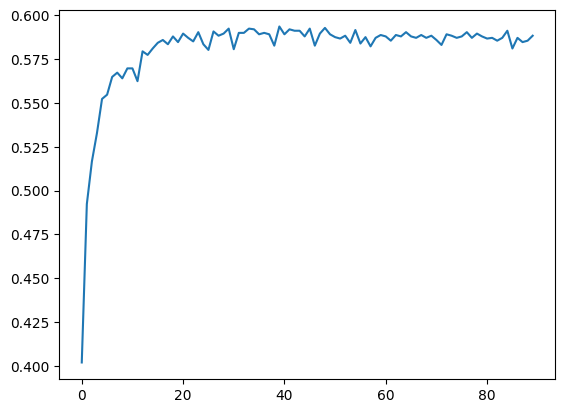

In [91]:
plt.plot(history_standard['test_acc'])

In [92]:
patch_size_to_test = 16
encoder_standard = MoiraiEncoder(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-{SIZE}"),
    prediction_length=patch_size_to_test,
    context_length=36,
    patch_size=patch_size_to_test,
    num_samples=100,
    target_dim=6,
    feat_dynamic_real_dim=0, 
    past_feat_dynamic_real_dim=0
)

clf_model_standard = MoiraiForClassification(
    moirai_encoder=encoder_standard, 
    num_classes=NUM_CLASSES, 
    num_vars=NUM_VARS,
    dropout = 0.3
)

clf_model_standard.set_tuning_mode(tune_mask=True)
clf_model_standard.reset_mask_weights

history_standard = train_and_evaluate(
    model=clf_model_standard,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=1000,
    lr=1e-3,
    weight_decay=0.01,
    optimizer_name="AdamW",
    scheduler_patience=15,
    early_stopping_patience=50,
    clip_grad_norm=1.0,
    device=DEVICE,
    verbose=False
)

# Optionnel : Affichage du meilleur score obtenu
best_standard_acc = max(history_standard['test_acc'])
print(f"\n Score final pour le masque unique : {best_standard_acc:.4f}")

Traianble params : 32654



 Score final pour le masque unique : 0.5929


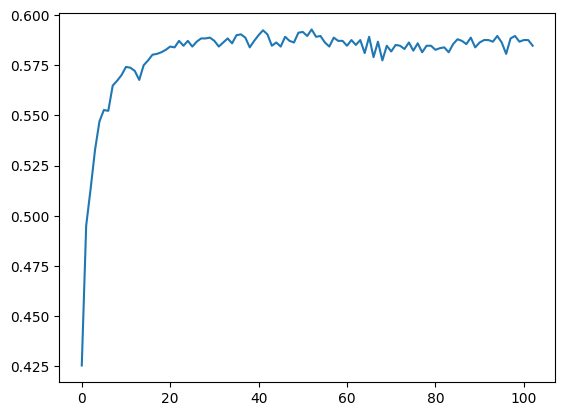

In [93]:
plt.plot(history_standard['test_acc'])

In [94]:
class MoiraiForClassification_VarMasks(nn.Module):
    def __init__(self, moirai_encoder, num_classes, num_vars, d_model=384, dropout_p=0.3):
        super().__init__()
        self.moirai = moirai_encoder
        self.num_vars = num_vars
        self.d_model = d_model
        
        self.var_mask_encoding = nn.Embedding(num_embeddings=num_vars, embedding_dim=d_model)
        
        self.dropout = nn.Dropout(p=dropout_p)
        self.head = nn.Linear(self.num_vars * d_model, num_classes)

    def forward(self, past_target, past_observed_target, past_is_pad):
        
        (
            target,
            observed_mask,
            sample_id,
            time_id,
            variate_id,
            prediction_mask,
        ) = self.moirai._convert(
            patch_size=self.moirai.hparams.patch_size,
            past_target=past_target,
            past_observed_target=past_observed_target,
            past_is_pad=past_is_pad,
        ) 

        patch_size_tensor = torch.ones_like(time_id, dtype=torch.long) * self.moirai.hparams.patch_size #

        loc, scale = self.moirai.module.scaler(
            target,
            observed_mask * ~prediction_mask.unsqueeze(-1),
            sample_id,
            variate_id,
        ) 
        scaled_target = (target - loc) / scale #
        
        reprs = self.moirai.module.in_proj(scaled_target, patch_size_tensor) #

        custom_masks = self.var_mask_encoding(variate_id)
        
        masked_reprs = torch.where(
            prediction_mask.unsqueeze(-1),
            custom_masks,
            reprs
        )

        encoded_reprs = self.moirai.module.encoder(
            masked_reprs,
            packed_attention_mask(sample_id),
            time_id=time_id,
            var_id=variate_id,
        ) 
    
        N, S, F = encoded_reprs.shape
        P = S // self.num_vars 
        
        reprs_reshaped = encoded_reprs.view(N, self.num_vars, P, F)
        
        mask_reprs = reprs_reshaped[:, :, -1, :]
        
        pooled = mask_reprs.reshape(N, -1)
        
        pooled = self.dropout(pooled)
        logits = self.head(pooled)
        return logits

    def set_tuning_mode(self):
        for param in self.moirai.parameters():
            param.requires_grad = False
            
        for param in self.var_mask_encoding.parameters():
            param.requires_grad = True
            
        for param in self.head.parameters():
            param.requires_grad = True
            
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Trainable params : {trainable_params}")

In [95]:
patch_size_to_test = 16
encoder_base = MoiraiEncoder(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-{SIZE}"),
    prediction_length=patch_size_to_test,
    context_length=36,
    patch_size=patch_size_to_test,
    num_samples=100,
    target_dim=6,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

clf_model_varmasks = MoiraiForClassification_VarMasks(
    moirai_encoder=encoder_base, 
    num_classes=NUM_CLASSES, 
    num_vars=NUM_VARS,
    dropout_p=0.3
)
clf_model_varmasks.set_tuning_mode()

history_varmasks = train_and_evaluate(
    model=clf_model_varmasks,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=1000,
    lr=1e-3,
    weight_decay=0.01,
    scheduler_patience=5,
    early_stopping_patience=50,
    clip_grad_norm=1.0,
    device=DEVICE,
    verbose = False
)

Trainable params : 34574


0.5823195458231955


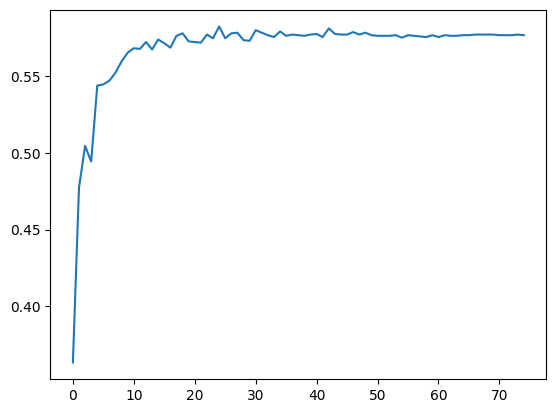

In [96]:
print(max(history_varmasks['test_acc']))
plt.plot(history_varmasks['test_acc'])